# 02 - QC, embedding and clustering

Week 2 deliverable. Builds on notebook 01: A2's status (background-looking
spots, flagged there as needing a data-driven follow-up), general per-library
QC given the ~70x depth spread already measured, then normalisation, PCA,
UMAP and Leiden clustering across all usable spots.

Per the project's naming rule, clusters are called `Cluster N` here -
biological labels are not assigned until notebook 03 examines marker genes.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
from sklearn.mixture import GaussianMixture

sys.path.insert(0, str(Path("..") / "src"))
import geo_loading as gl

RAW = Path("..") / "data" / "raw"
TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
PROCESSED_OUT = Path("..") / "data" / "processed"
for d in (TABLES_OUT, FIGURES_OUT, PROCESSED_OUT):
    d.mkdir(parents=True, exist_ok=True)

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"


## 1. Load, and compute QC metrics

Images are not needed for every library here (only for the A2 check below),
so loading without them is faster.

In [2]:
%%time
adatas = gl.load_all(RAW, only_in_tissue=True, load_images=False)
for lib, a in adatas.items():
    a.var["mt"] = a.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(a, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
print(f"loaded {len(adatas)} libraries, {sum(a.n_obs for a in adatas.values())} spots total")


loaded 19 libraries, 65101 spots total
CPU times: total: 1min 44s
Wall time: 1min 11s


## 2. A2's background-looking spots

Notebook 01 flagged, from a coarse image overlay, that A2's in-tissue spot
mask extends past the tissue outline, and labelled that read as inferred,
not proven - worth a data-driven check. That check: fit a 2-component
Gaussian mixture to A2's own `log1p(total_counts)`, per spot. If A2 really
is a mix of a background population and a real-signal population, this
should recover a clean split.

In [3]:
a2 = adatas["A2"]
total_counts = np.asarray(a2.X.sum(axis=1)).ravel()
log_counts = np.log1p(total_counts)

gmm = GaussianMixture(n_components=2, random_state=0, n_init=5).fit(log_counts.reshape(-1, 1))
bg_component = np.argmin(gmm.means_.ravel())
a2_is_background = gmm.predict(log_counts.reshape(-1, 1)) == bg_component

# is this actually a clean split, or did the GMM just carve up a continuum?
# check by sorting spots by total_counts and counting how many times the label
# switches - a clean split gives 1 switch (a single threshold); many switches
# would mean the two "components" are interleaved by count, i.e. not a real split.
order = np.argsort(total_counts)
n_switches = int((np.diff(a2_is_background[order].astype(int)) != 0).sum())
threshold = total_counts[order][np.where(np.diff(a2_is_background[order].astype(int)) != 0)[0][0]]

print(f"component means (log1p total_counts): {gmm.means_.ravel()}")
print(f"n switches when sorted by total_counts: {n_switches} (1 means a single clean threshold)")
print(f"equivalent threshold: total_counts <= {threshold:.0f} -> background")
print(f"background: {a2_is_background.sum()} spots, kept: {(~a2_is_background).sum()} spots")

known_zero = a2.obs["expression_zero_filled"].values
print(f"of the 42 already-known all-zero spots, {a2_is_background[known_zero].sum()}/{known_zero.sum()} "
      "were independently placed in the background component")
assert n_switches == 1, "GMM split on total_counts is not a single clean threshold - re-examine before using it"


component means (log1p total_counts): [3.3690727 5.578759 ]
n switches when sorted by total_counts: 1 (1 means a single clean threshold)
equivalent threshold: total_counts <= 121 -> background
background: 2206 spots, kept: 1161 spots
of the 42 already-known all-zero spots, 42/42 were independently placed in the background component


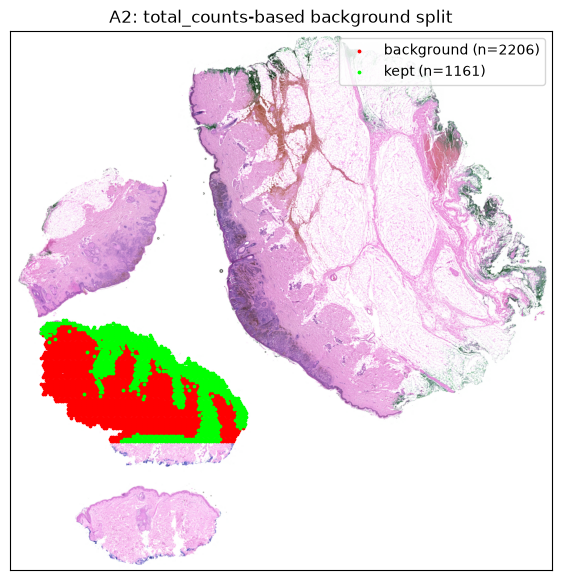

In [4]:
# spatial cross-check against A2's own image (loaded separately - only needed here)
a2_gsm = gl.list_libraries(RAW).set_index("library").loc["A2", "gsm"]
a2_with_img = gl.load_slide(RAW, a2_gsm, only_in_tissue=True, load_images=True)["A2"]
img = a2_with_img.uns["spatial"]["A2"]["images"]["hires"]
sf = a2_with_img.uns["spatial"]["A2"]["scalefactors"]["tissue_hires_scalef"]
xy = a2_with_img.obsm["spatial"] * sf

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img)
ax.scatter(xy[a2_is_background, 0], xy[a2_is_background, 1], s=3, c="red",
           label=f"background (n={a2_is_background.sum()})")
ax.scatter(xy[~a2_is_background, 0], xy[~a2_is_background, 1], s=3, c="lime",
           label=f"kept (n={(~a2_is_background).sum()})")
ax.invert_yaxis()
ax.legend()
ax.set_title("A2: total_counts-based background split")
ax.set_xticks([]); ax.set_yticks([])
plt.savefig(FIGURES_OUT / "02_A2_background_split.png", dpi=150, bbox_inches="tight")
plt.show()


**Observed:** the two populations are *not* spatially separated into a
clean "on tissue" region vs. "off tissue" region - kept and background spots
are interleaved across the same piece, with a density gradient (more kept
spots toward one side). That revises notebook 01's coarser read: this isn't
obviously a coordinate mismatch with the mask sitting on blank image
background; it looks more like a real (if faint/lower-quality) piece of
tissue with patchy signal across it. Either way, the `total_counts` split
above is a legitimate, data-driven way to keep only the spots with real
signal, verified two ways: it's a single clean threshold (not the GMM
carving noise into two arbitrary halves), and it recovers all 42 already-known
all-zero spots independently.

A2 keeps its 1,161 spots with usable signal; its other spots are dropped
before QC and clustering below.

In [5]:
adatas["A2"] = a2[~a2_is_background].copy()
print(f"A2 now has {adatas['A2'].n_obs} spots (was {a2.n_obs})")


A2 now has 1161 spots (was 3367)


## 3. Per-library QC

The ~70x depth spread across libraries (notebook 01, section 6) means a
single fixed threshold (e.g. "drop spots under 500 genes") would be
appropriate for a deep library and would gut a shallow-but-real one like B8
(median 70 genes/spot). Outliers are instead flagged *within each library's
own distribution*, using a median-absolute-deviation rule (the same one used
in the sc-best-practices QC chapter): a spot is an outlier if it sits more
than `nmads` MADs from its own library's median, on log1p(total_counts),
log1p(n_genes_by_counts), or pct_counts_mt.

In [6]:
def is_outlier(values, nmads):
    med = np.median(values)
    mad = median_abs_deviation(values)
    if mad == 0:
        return np.zeros(len(values), dtype=bool)
    return (values < med - nmads * mad) | (values > med + nmads * mad)

qc_summary = []
for lib, a in adatas.items():
    log_counts = np.log1p(a.obs["total_counts"].values)
    log_genes = np.log1p(a.obs["n_genes_by_counts"].values)
    pct_mt = a.obs["pct_counts_mt"].values
    outlier = (is_outlier(log_counts, 5) | is_outlier(log_genes, 5) | is_outlier(pct_mt, 3))
    a.obs["qc_outlier"] = outlier
    qc_summary.append({"library": lib, "n_before": a.n_obs, "n_outlier": int(outlier.sum()),
                        "n_after": int((~outlier).sum())})

qc_summary_df = pd.DataFrame(qc_summary).sort_values("library")
print(qc_summary_df.to_string(index=False))
print(f"\ntotal spots: {qc_summary_df['n_before'].sum()} -> {qc_summary_df['n_after'].sum()} "
      f"after per-library MAD-based QC ({qc_summary_df['n_outlier'].sum()} removed)")


library  n_before  n_outlier  n_after
    A16      5195        553     4642
    A17      2274        243     2031
     A2      1161        101     1060
    A21      2260        144     2116
    A22      4326          2     4324
    A23      2782        227     2555
    A24      6165        358     5807
    A34      4151        255     3896
     A7      2892          1     2891
     B1      3952        593     3359
    B13      3614        241     3373
    B14      2206        169     2037
    B15      3171        169     3002
  B38_2      2100        182     1918
  B38ex      1861        157     1704
     B4      6415        801     5614
     B8      5780        432     5348
    D20      1089        162      927
     D3      1501        121     1380

total spots: 62895 -> 57984 after per-library MAD-based QC (4911 removed)


In [7]:
adatas = {lib: a[~a.obs["qc_outlier"]].copy() for lib, a in adatas.items()}


## 4. Restricting to the shared gene panel

Two feature panels exist (37,082 vs 18,085 probes); the smaller is a strict
subset of the larger (checked here, not assumed), so the joint analysis
below uses the intersection - every included gene was actually measured in
every library.

In [8]:
panel_sets = {lib: set(a.var["gene_id"]) for lib, a in adatas.items()}
small_panel = min(panel_sets.values(), key=len)
large_panel = max(panel_sets.values(), key=len)
assert small_panel <= large_panel, "the smaller panel is not a subset of the larger one - re-check"
shared_genes = set.intersection(*panel_sets.values())
print(f"panel sizes present: {sorted(set(len(s) for s in panel_sets.values()))}")
print(f"shared gene set used for the joint analysis: {len(shared_genes)} genes")


panel sizes present: [18085, 37082]
shared gene set used for the joint analysis: 18085 genes


## 5. Concatenating all libraries

In [9]:
%%time
for lib, a in adatas.items():
    a.obs_names = [f"{lib}_{bc}" for bc in a.obs["barcode"]]
    a.var["gene_symbol"] = a.var_names  # keep the display symbol before switching the join key
    a.var_names = a.var["gene_id"].values  # gene_id is the reliable join key (symbols repeat)

combined = ad.concat(adatas, join="inner", merge="first")
combined.var["gene_symbol"] = adatas["D20"].var.loc[combined.var_names, "gene_symbol"].values
combined.var_names = combined.var["gene_symbol"].values
combined.var_names_make_unique()
combined.layers["counts"] = combined.X.copy()
print(combined)


AnnData object with n_obs × n_vars = 57984 × 18085
    obs: 'gsm', 'library', 'barcode', 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'barcodes_inferred', 'expression_zero_filled', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'qc_outlier'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'
    layers: None (.X), 'counts'
CPU times: total: 7.83 s
Wall time: 7.99 s


In [10]:
s1 = pd.read_excel(RAW / "supplementary" / "can-25-2934_supplementary_tables_suppst1.xlsx",
                    sheet_name="Supplementary Table S1", header=4)
s1 = s1.rename(columns={"Visium ID": "library", "Patient#": "patient"})
s1["library"] = s1["library"].astype(str).str.strip()
s1["patient"] = s1["patient"].astype(str).str.replace("\xa0", "", regex=False).str.strip().astype(int)
s1 = s1.set_index("library")

def lookup_patient(lib):
    if lib in s1.index:
        return s1.loc[lib, "patient"]
    if lib in ("B38ex", "B38_2") and "B38" in s1.index:
        return s1.loc["B38", "patient"]
    return None

combined.obs["patient"] = combined.obs["library"].map(lookup_patient).astype(str)
print(combined.obs[["library", "patient"]].drop_duplicates().sort_values("library").to_string(index=False))


library patient
    A16      16
    A17      17
     A2       2
    A21      21
    A22      22
    A23      23
    A24      24
    A34      34
     A7       7
     B1       1
    B13      13
    B14      14
    B15      15
  B38_2      38
  B38ex      38
     B4       4
     B8       8
    D20      20
     D3       3


## 6. Normalisation, HVGs, PCA

Total-count normalisation directly targets the depth confound between
libraries. Highly-variable genes are selected with `batch_key="library"` so
a gene isn't picked just because it differs *between* libraries/depths.

In [11]:
sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)
sc.pp.highly_variable_genes(combined, n_top_genes=2000, batch_key="library")
print(f"{combined.var['highly_variable'].sum()} HVGs selected out of {combined.n_vars}")
sc.pp.pca(combined, n_comps=50)


2000 HVGs selected out of 18085


## 7. Neighbours, UMAP, Leiden

In [12]:
%%time
sc.pp.neighbors(combined, n_neighbors=15, n_pcs=50)
sc.tl.umap(combined)
sc.tl.leiden(combined, resolution=1.0, key_added="leiden", flavor="igraph", n_iterations=2)
combined.obs["cluster"] = "Cluster " + combined.obs["leiden"].astype(str)
print(f"{combined.obs['leiden'].nunique()} clusters, sizes:")
print(combined.obs["cluster"].value_counts().sort_index())


C:\Users\LENOVO\.venvs\melanoma-sg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


26 clusters, sizes:
cluster
Cluster 0     2042
Cluster 1     2283
Cluster 10     569
Cluster 11    2624
Cluster 12    2119
Cluster 13    3034
Cluster 14    1307
Cluster 15     838
Cluster 16    8000
Cluster 17    4124
Cluster 18    1461
Cluster 19     743
Cluster 2     1734
Cluster 20    1665
Cluster 21    1938
Cluster 22    3335
Cluster 23    1713
Cluster 24     354
Cluster 25      59
Cluster 3     2460
Cluster 4     2450
Cluster 5     3934
Cluster 6     1861
Cluster 7     4148
Cluster 8     2224
Cluster 9      965
Name: count, dtype: int64
CPU times: total: 4min 23s
Wall time: 3min 58s


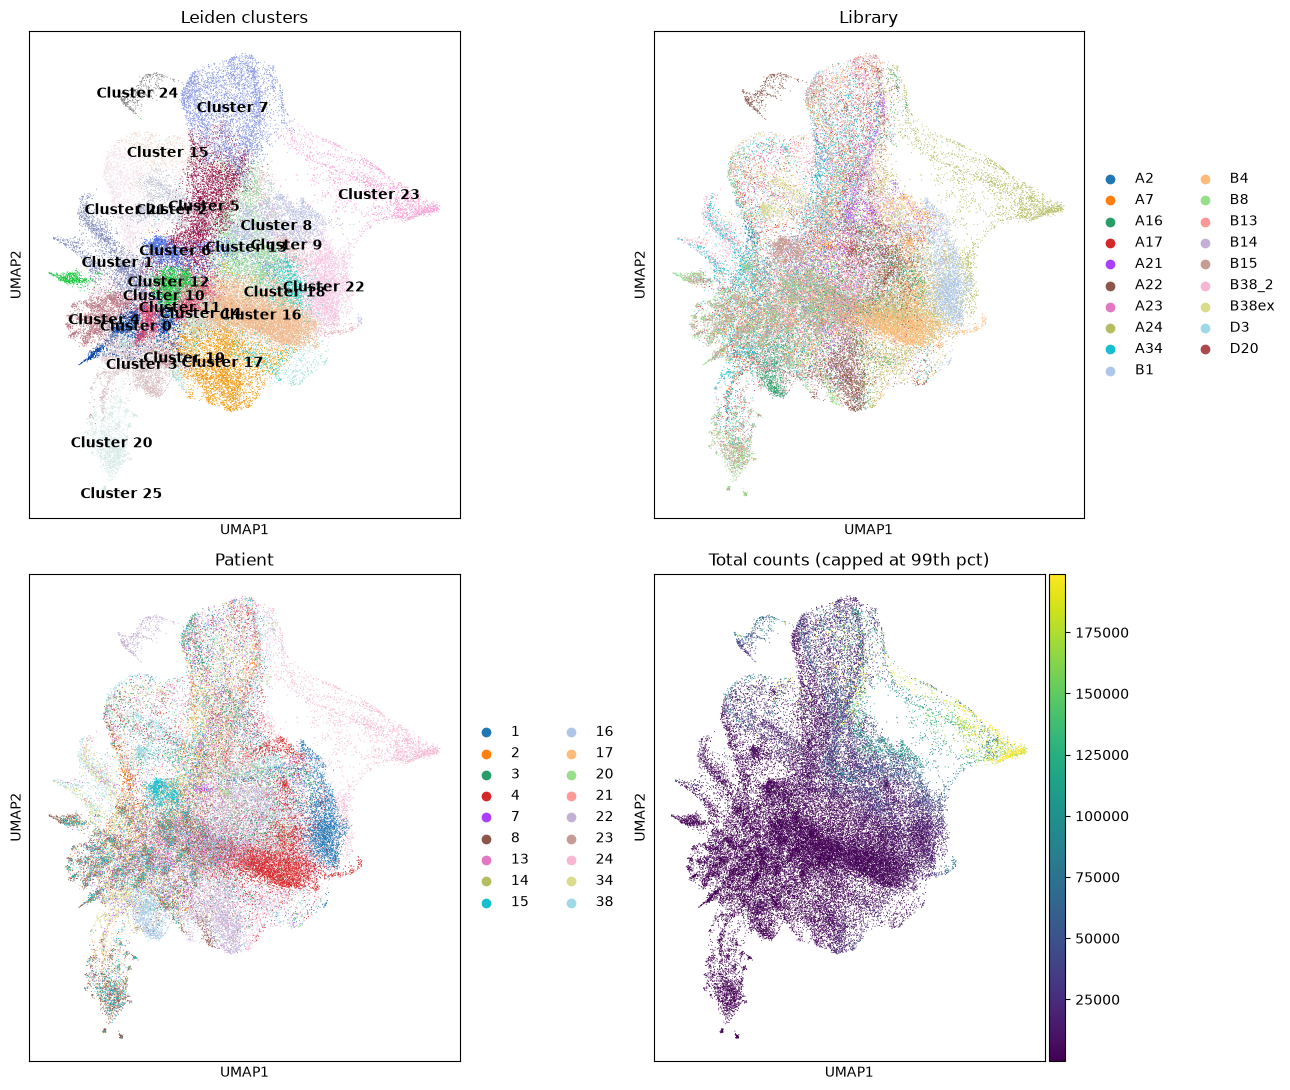

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
sc.pl.umap(combined, color="cluster", ax=axes[0, 0], show=False, legend_loc="on data", title="Leiden clusters")
sc.pl.umap(combined, color="library", ax=axes[0, 1], show=False, title="Library")
sc.pl.umap(combined, color="patient", ax=axes[1, 0], show=False, title="Patient")
# linear total_counts is dominated by a handful of extreme-depth spots; cap at the
# 99th percentile so the plot actually shows the depth gradient, not just outliers
counts_vmax = float(np.percentile(combined.obs["total_counts"], 99))
sc.pl.umap(combined, color="total_counts", ax=axes[1, 1], show=False,
           title="Total counts (capped at 99th pct)", vmax=counts_vmax)
plt.tight_layout()
plt.savefig(FIGURES_OUT / "02_umap_overview.png", dpi=150)
plt.show()


## 8. Do the clusters reflect biology, or batch?

This is checked directly rather than assumed either way: how concentrated is
each cluster in a small number of libraries/patients? A cluster made almost
entirely of spots from one library is a batch artefact candidate, not
(necessarily) a biological compartment - flagged here for notebook 03 to
take into account, not resolved by this notebook.

In [14]:
lib_frac = pd.crosstab(combined.obs["cluster"], combined.obs["library"], normalize="index")
patient_frac = pd.crosstab(combined.obs["cluster"], combined.obs["patient"], normalize="index")
cluster_purity = pd.DataFrame({
    "n_spots": combined.obs["cluster"].value_counts(),
    "top_library_frac": lib_frac.max(axis=1),
    "top_library": lib_frac.idxmax(axis=1),
    "n_patients_present": (patient_frac > 0).sum(axis=1),
    "top_patient_frac": patient_frac.max(axis=1),
}).sort_index()
print(cluster_purity.to_string())

flagged = cluster_purity[cluster_purity["top_library_frac"] > 0.8]
print(f"\nFlagged as likely batch/technical (>80% of spots from one library): "
      f"{list(flagged.index)}")
print(flagged[["n_spots", "top_library_frac", "top_library", "n_patients_present"]].to_string())


            n_spots  top_library_frac top_library  n_patients_present  top_patient_frac
cluster                                                                                
Cluster 0      2042          0.190989          B8                  16          0.190989
Cluster 1      2283          0.393780         A34                  16          0.393780
Cluster 2      1734          0.606690       B38ex                  11          0.631488
Cluster 3      2460          0.408943         A16                  16          0.408943
Cluster 4      2450          0.374286          B8                  15          0.374286
Cluster 5      3934          0.204372         A34                  18          0.204372
Cluster 6      1861          0.379903         B15                  17          0.379903
Cluster 7      4148          0.092334         B13                  18          0.092334
Cluster 8      2224          0.253147          B1                  17          0.253147
Cluster 9       965          0.3

## 9. Saving outputs

In [15]:
combined.write_h5ad(PROCESSED_OUT / "02_combined_qc_clustered.h5ad")

spot_table = combined.obs[["library", "patient", "gsm", "cluster", "total_counts",
                           "n_genes_by_counts", "pct_counts_mt"]].copy()
spot_table.index.name = "spot_id"
spot_table.to_csv(TABLES_OUT / "spot_level_clusters.csv")

cluster_purity.to_csv(TABLES_OUT / "cluster_library_patient_purity.csv")
print("wrote data/processed/02_combined_qc_clustered.h5ad, "
      "results/tables/spot_level_clusters.csv, "
      "results/tables/cluster_library_patient_purity.csv")


wrote data/processed/02_combined_qc_clustered.h5ad, results/tables/spot_level_clusters.csv, results/tables/cluster_library_patient_purity.csv


## 10. Summary

In [16]:
print("Observed, from this notebook's own computation:")
print(f"- A2: {a2_is_background.sum()} of its 3,367 in-tissue spots dropped as background "
      f"(data-driven split, see section 2); {(~a2_is_background).sum()} kept")
print(f"- General per-library QC (section 3, post A2-background-drop): {qc_summary_df['n_before'].sum()} -> "
      f"{qc_summary_df['n_after'].sum()} spots ({qc_summary_df['n_outlier'].sum()} removed)")
print(f"- Joint analysis uses {len(shared_genes)} shared genes across all 19 libraries")
print(f"- {combined.n_obs} spots x {combined.n_vars} genes entered clustering; "
      f"{combined.obs['leiden'].nunique()} Leiden clusters found (resolution=1.0)")
worst_cluster = cluster_purity["top_library_frac"].idxmax()
print(f"- Batch check: the most library-concentrated cluster ({worst_cluster}) has "
      f"{cluster_purity.loc[worst_cluster, 'top_library_frac']:.0%} of its spots from a single library "
      f"({cluster_purity.loc[worst_cluster, 'top_library']})")
print(f"- {len(flagged)} of {combined.obs['cluster'].nunique()} clusters are >80% one library "
      f"({list(flagged.index)}) - likely batch/technical, not biology")
print(f"- The other {combined.obs['cluster'].nunique() - len(flagged)} clusters each span "
      f"{cluster_purity.loc[~cluster_purity.index.isin(flagged.index), 'n_patients_present'].min()}"
      f"-{cluster_purity['n_patients_present'].max()} of 18 patients - not obviously single-library artifacts")


Observed, from this notebook's own computation:
- A2: 2206 of its 3,367 in-tissue spots dropped as background (data-driven split, see section 2); 1161 kept
- General per-library QC (section 3, post A2-background-drop): 62895 -> 57984 spots (4911 removed)
- Joint analysis uses 18085 shared genes across all 19 libraries
- 57984 spots x 18085 genes entered clustering; 26 Leiden clusters found (resolution=1.0)
- Batch check: the most library-concentrated cluster (Cluster 24) has 100% of its spots from a single library (A22)
- 3 of 26 clusters are >80% one library (['Cluster 23', 'Cluster 24', 'Cluster 25']) - likely batch/technical, not biology
- The other 23 clusters each span 11-18 of 18 patients - not obviously single-library artifacts


**Carried into notebook 03 (DE, annotation, enrichment):** clusters are
still unnamed ("Cluster N") until marker genes are examined there. If
section 8's purity table shows clusters dominated by single libraries/
patients, that has to be addressed (e.g. treated as a technical cluster, or
batch-corrected) before any biological label is attached - decide that with
the actual numbers in `results/tables/cluster_library_patient_purity.csv` in
hand, not from this summary alone.